<a href="https://colab.research.google.com/github/mp371366/ML/blob/main/LAB03.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# LAB 03

## Logistic regression

We consider dataset with heart disease.

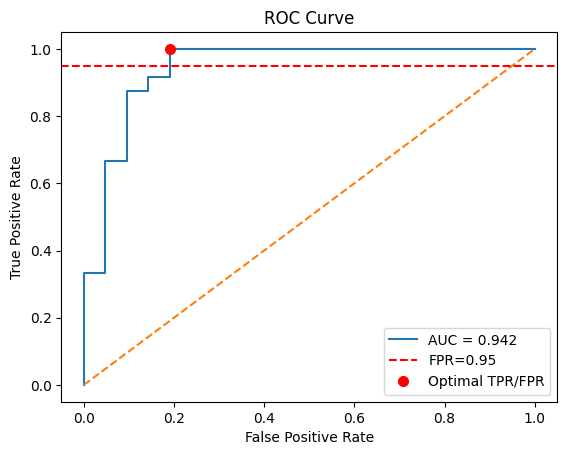

In [2]:
# 1. Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, roc_auc_score

# 2. Load dataset
url = 'https://raw.githubusercontent.com/mp371366/ML/main/heart.csv'
df = pd.read_csv(url)

# 3. Features and target
X = df.drop("target", axis=1)   # input features
y = df["target"]                # output (0 or 1)

# 4. train (70%), validation (15%) and test (15%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42
)

# 5. Train logistic regression
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# 6. Predict probabilities (IMPORTANT for ROC!)
y_prob = model.predict_proba(X_val)[:, 1]

# 7. Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_val, y_prob)

# 8. Compute AUC
auc = roc_auc_score(y_val, y_prob)

# 9. Optimal threshold
tpr_level = 0.95
acceptable = tpr >= tpr_level
filtered_thresholds = thresholds[acceptable]
filtered_tpr = tpr[acceptable]
filtered_fpr = fpr[acceptable]

# Choose the threshold with the lowest FPR among them
idx = np.argmin(filtered_fpr)
optimal_threshold = filtered_thresholds[idx]

# 9. Plot ROC curve
plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")  # random model
plt.axhline(y=tpr_level, color='red', linestyle='--', label=f'FPR={tpr_level}')
plt.plot(filtered_fpr[idx], filtered_tpr[idx], 'ro', markersize=7, label='Optimal TPR/FPR')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

## Optimal threshold

In this case we want to maximize `TPR` (let's say `90%`) and keep `FPR` low.

In [3]:
print(f"Optimal Threshold: {optimal_threshold:.3f}")
print(f"TPR: {filtered_tpr[idx]:.3f}; FPR: {filtered_fpr[idx]:.3f}")

Optimal Threshold: 0.340
TPR: 1.000; FPR: 0.190


## Metrics for test dataset

In [4]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

y_prob_test = model.predict_proba(X_test)[:, 1]

# Convert probabilities to binary predictions
y_pred_class = (y_prob_test >= optimal_threshold).astype(int)

# Accuracy
accuracy = accuracy_score(y_test, y_pred_class)

# Precision & Recall (Recall = Sensitivity)
precision = precision_score(y_test, y_pred_class)
recall = recall_score(y_test, y_pred_class)

# F1 Score
f1 = f1_score(y_test, y_pred_class)

# Confusion Matrix
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_class).ravel()

# Specificity = TN / (TN + FP)
specificity = tn / (tn + fp)

# Sensitivity (Recall) = TP / (TP + FN)
sensitivity = tp / (tp + fn)

print(f"Accuracy: {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall (Sensitivity): {recall:.3f}")
print(f"F1-Score: {f1:.3f}")
print(f"Specificity: {specificity:.3f}")

Accuracy: 0.783
Precision: 0.808
Recall (Sensitivity): 0.808
F1-Score: 0.808
Specificity: 0.750


The accuracy (level of true predictions to all predictions) is on quite well level.
The precision is well (level of true positives to all positives predictions).
Sensitivity should be better in our case.
F1-Score is quite well (both precision and recall are the same, so the harmonic average).
Specificity is well in our case.

## Questions

### Would a different threshold yield better results?

Lowering the threshold makes more predictions classified as positive, which increase sensitivity (you catch more true positivities)
and specificity goes down, because of more false positives. On the other hand, increasing the threshold decrease sensitivity and increase specificity because of less both true and false positives.

### How do you define "better" results?

Sensitivity (Recall / True Positive Rate) measures how many actual positives are correctly detected. High sensitivity means few false negatives. This is valuable when missing a positive case is costly or dangerous. Examples where high sensitivity is critical:
- disease detection (cancer, COVID-19, HIV),
- missing a sick patient (false negative) could be life-threatening,
- fraud detection - missing a fraudulent transaction could cause huge financial loss.

Specificity (True Negative Rate) measures how many actual negatives are correctly identified. High specificity means few false positives. This is valuable when falsely labeling something positive has high cost.
Examples where high specificity is critical:
- screening for rare diseases with costly treatment,
- treating a healthy patient is expensive, risky, or invasive,
- spam email filtering - misclassifying legitimate email as spam is disruptive.

Trade-off: one may accept more false positives (lower specificity) because catching all true positives is essential.

Conclusion: whether higher specificity or higher sensitivity is “more valuable” depends entirely on the context and the consequences of false positives vs false negatives.

### How does a ROC curve help in this process?

A ROC (Receiver Operating Characteristic) curve is a tool for understanding how classification threshold affects the trade-off between sensitivity (True Positive Rate, TPR) and specificity (True Negative Rate, TNR).

The ROC curve plots:
- Y-axis: True Positive Rate (TPR = Sensitivity)
- X-axis: False Positive Rate (FPR = 1 − Specificity)

Each point on the curve corresponds to a different threshold in your classifier.
By looking at the curve, you can see how TPR and FPR change as you adjust the threshold.

Lower threshold: More predictions are classified as positive → TPR increases (catch more true positives), but FPR increases (more false positives).
Higher threshold: Fewer positives predicted → FPR decreases, but TPR decreases.
The ROC curve makes this trade-off visible, helping pick a threshold that balances sensitivity and specificity according to a problem.

### How do you select the optimal threshold using the ROC curve?

Selecting the decision threshold in a classification model is not just a technical step — it depends heavily on the task requirements and the costs of false positives vs false negatives.

1. Default Threshold (0.5).
Logistic regression outputs probabilities, and the default threshold is 0.5.
Works well for balanced datasets where false positives and false negatives have similar consequences.
Limitation: Often suboptimal when classes are imbalanced or consequences differ.

2. Maximizing Youden’s $J$ Statistic.
Formula:
$$ J=Sensitivity+Specificity−1=TPR−FPR $$
Strategy: Pick the threshold that maximizes J, balancing sensitivity and specificity.
Best for: General-purpose tasks where both types of errors are equally important.

3. Constraint-Based Threshold Selection.
Define a maximum acceptable FPR or minimum required TPR.
Select the threshold that meets the constraint while optimizing the other metric.
Example: Disease detection.
TPR (sensitivity) must be ≥ 0.95 to catch almost all sick patients.
Choose the lowest threshold that satisfies this sensitivity, even if FPR increases.

4. Cost-Sensitive Thresholding.
Assign monetary or clinical costs to false positives (FP) and false negatives (FN).
Compute expected cost for each threshold:
$$ Expected \text{ } cost=FP×C_{FP} + FN×C_{FN} $$
Pick the threshold that minimizes the total expected cost.
Best for: Medical treatments, fraud detection, or industrial defect detection.

5. Precision-Recall-Based Thresholding.
For highly imbalanced datasets (rare events), ROC curves can be misleading.
Use the Precision-Recall (PR) curve.
High precision → few false positives.
High recall → few false negatives.
Select threshold based on desired balance between precision and recall.

6. Business or Regulatory Requirements.
Sometimes thresholds are set externally by policy or regulation.
Examples:
- FDA-approved diagnostic tests may require ≥ 99% sensitivity.
- Spam filters may prioritize specificity to avoid blocking legitimate emails.

7. Visual/Graphical Strategy.
Plot metrics vs thresholds:
- TPR (sensitivity)
- FPR (1 − specificity)
- F1-score, precision, accuracy
Pick a threshold where the desired trade-off is visually apparent.
Helps communicate decisions to stakeholders.

In our example we used the 3rd strategy to maximize TPR while keeping FTR as low as possible.

### What is the AUC metric and how is it useful?

1. Definition

AUC stands for Area Under the ROC Curve.
AUC measures the entire two-dimensional area under this curve, from (0,0) to (1,1).

Interpretation:
- AUC = 1 → perfect classifier (all positives and negatives correctly separated)
- AUC = 0.5 → random guessing (no discrimination)
- 0.5 < AUC < 1 → classifier has some ability to distinguish positives from negatives

2. Why AUC is Useful?

Threshold-independent evaluation.
Unlike accuracy, AUC evaluates the model across all possible thresholds, not just a single one.
Useful when you haven’t chosen the final threshold yet.
Handles class imbalance well.
Accuracy can be misleading if the dataset is imbalanced (e.g., rare disease detection).
AUC focuses on ranking predictions, so it’s more robust.

Probability ranking ability.
AUC tells you how well the model ranks a random positive higher than a random negative.
Formally:
$$AUC=P(score \text{ } of \text{ } positive>score \text{ } of \text{ } negative)$$

In out case AUC is high, which can indicate, that the regression is quite good.